In [95]:
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.integrate import trapezoid
from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk

In [96]:
search_result = search_lightcurve("AU Mic") 
lc2min = search_result[8].download() 
lc2 = lc2min.remove_nans().remove_outliers()
lc2 = lc2[lc2.quality == 0]
lc2_m = lc2.normalize().remove_nans()

x2min = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
y2min = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
yerr2min = np.ascontiguousarray(lc2_m.flux_err, dtype=np.float64)
lcquality = np.ascontiguousarray(lc2_m.quality, dtype=np.float64)

vetores = [
    [2036.7054, 2036.71023],
    [2037.4429, 2037.44941],
    [2041.204,2041.404],
    [2047.4961,2047.6481],
    [2051.4334,2051.6652],
    [2053.416,2053.715],
    [2058.108,2058.276],
    [2037.663,2037.787],
    [2058.8291,2058.8768],
    [2037.6736, 2037.6953],
    [2037.71922, 2037.7435],
    [2039.18134, 2039.1888],
    [2039.26492, 2039.26775],
    [2039.34872, 2039.35791],
    [2039.82051, 2039.84413],
    [2042.48425, 2042.49485],
    [2042.50061, 2042.51093],
    [2047.21325, 2047.2352],
    [2047.34522, 2047.35652],
    [2047.6273,2047.6467],
    [2049.6324,2049.8531],
    [2051.1540,2051.2290],
    [2051.4325,2051.5796],
    [2054.2655,2054.3711],
    [2051.438,2051.772],
    [2055.8981,2055.9470],
    [2056.8229,2056.8623],
    [2047.5068, 2047.6352],
    [2047.62795, 2047.63086],
    [2047.83154, 2047.83609],
    [2047.84043, 2047.84221],
    [2049.73685, 2049.7421],
    [2050.78104, 2050.78403],
    [2050.85602, 2050.8691],
    [2050.31549, 2050.31673],
    [2051.44131, 2051.45145],
    [2053.08171, 2053.08283],
    [2053.4107, 2053.6154],
    [2042.4797,2042.5663],
    [2058.8328,2058.8928],
    [2055.90268, 2055.90634],
    [2056.26941, 2056.27345],
    [2056.68717, 2056.70876],
    [2056.8243, 2056.83581],
    [2056.90861, 2056.92518],
    [2057.7945, 2057.9036],
    [2058.24052, 2058.24389],
    [2058.1191,2058.2976],
    [2058.8317,2058.8757],
    [2059.10883, 2059.11091],
    [2058.803,2058.912],
    [2056.9016,2057.1076],
    [2059.54703, 2059.56109]
]

vetor_true = [False]*len(x2min)


#indices = []
#indices = np.where((x2min>=vetores[0][0]) & (x2min<=vetores[0][1]))

for j in range(len(x2min)):
    for i in range(len(vetores)):
        if (x2min[j]>=vetores[i][0]) and (x2min[j]<=vetores[i][1]):
            vetor_true[j] = True

mascara = np.array(vetor_true)

#flcd = lc2_m.flatten(window_length=320, polyorder=4, return_trend=True, break_tolerance=100, niters=4, sigma=2.5, mask=mascara)
#x_detrend = np.ascontiguousarray(flcd[1].time.value, dtype=np.float64) 
#y_detrend = np.ascontiguousarray(flcd[1].flux, dtype=np.float64)
#yerr_detrend= np.ascontiguousarray(flcd[1].flux_err, dtype=np.float64)

flcd = lc2_m.flatten(window_length=320, polyorder=4, return_trend=False, break_tolerance=100, niters=4, sigma=2.5, mask=mascara)
x_detrend = np.ascontiguousarray(flcd.time.value, dtype=np.float64) 
y_detrend = np.ascontiguousarray(flcd.flux, dtype=np.float64)
yerr_detrend= np.ascontiguousarray(flcd.flux_err, dtype=np.float64)

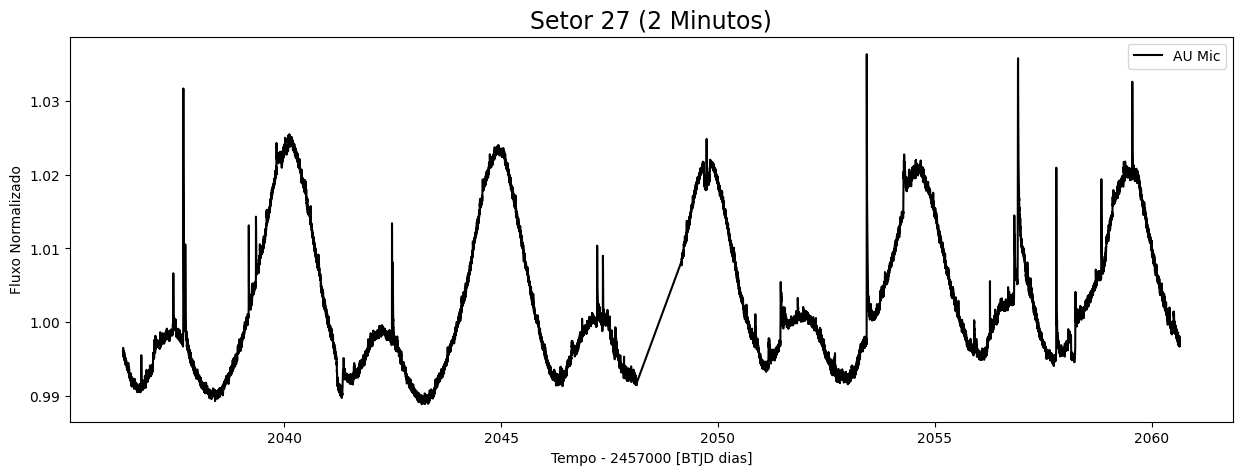

In [97]:

fig, ax = plt.subplots(1, 1, figsize=(15, 5))

# Plot dos dados originais
ax.plot(x2min, y2min, 'k-', label='AU Mic')

# Plot da tendência ajustada
#ax.plot(x_detrend,y_detrend, linewidth=3, label="Ajuste")

ax.set_title('Setor 27 (2 Minutos)', fontsize=17)
ax.set_ylabel("Fluxo Normalizado")
ax.set_xlabel("Tempo - 2457000 [BTJD dias]")

# Adicione outras configurações do gráfico, se necessário

ax.legend()
plt.show()

In [98]:
flcd.to_fits(path='lightcurve_02.fits', overwrite=True)
#Transformando os arquivos em fits e salvando 
from astropy.io import fits
hdu = fits.open('lightcurve_02.fits')
type(hdu)

from astropy.table import Table
dat = Table.read('lightcurve_02.fits', format='fits')
df = dat.to_pandas()
print(df.isna().sum()) #Contagem de dados nans nas colunas
df = df.dropna(subset=['TIME']) 
df = df.dropna(subset=['QUALITY']) # retirar valores 
#print(df.isna().sum())
df.drop(df[df.QUALITY>0].index ,inplace=True) # exclui linhas onde flag com raios cósmicos

TIME          0
FLUX          0
FLUX_ERR      0
CADENCENO     0
MOM_CENTR1    0
MOM_CENTR2    0
QUALITY       0
dtype: int64


In [99]:
%matplotlib inline
time=df["TIME"] # tempo
flux=df["FLUX"] #flux
s=df["QUALITY"] # sap_quality
sf  = df['QUALITY'] > 1 # filtra flag com valores maiores que 1 ou seja flag 128 e 8192, são raios cósmicos
#from scipy.signal import savgol_filter
rf = np.mean(flux)/np.mean(flux) #Fluxo relativo

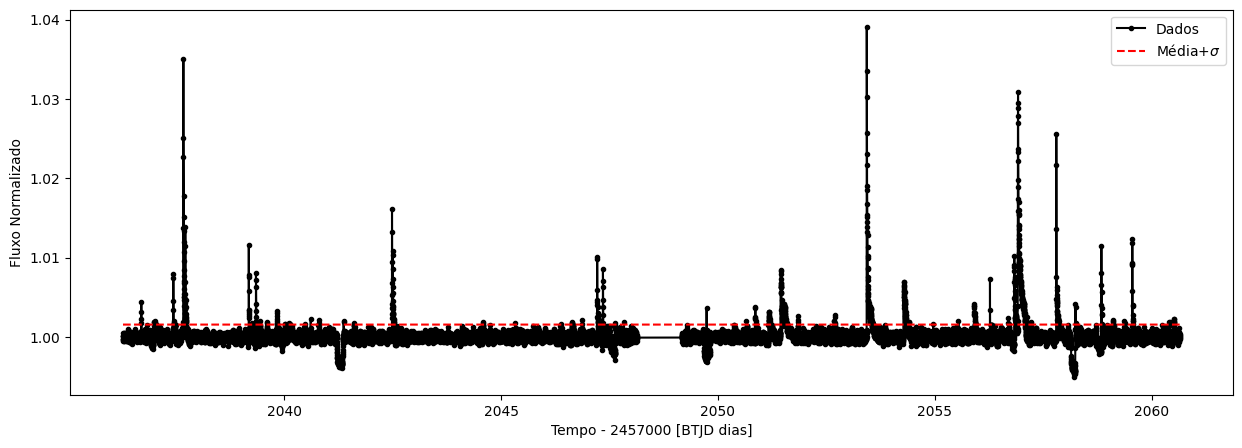

In [100]:
#%matplotlib notebook
#Calculando a média simples dos dados 
y_mean = [np.median(flux)]*len(time)

fig,ax = plt.subplots(1,1,figsize=(15,5))

data_line = ax.plot(time,flux, label='Dados', marker='.', color='black')

mean_line = ax.plot(time,y_mean+np.array(np.std(flux)), label='Média+$\sigma$', linestyle='--', color = 'red')
#mean_line = ax.plot(time,y_mean+np.std(flux), label='Mean+std', linestyle='--', color = 'red')

#Legenda
legend = ax.legend(loc='upper right')
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()
plt.show()

[0.99962676 1.0025866  1.0100889  1.00985    1.0059928  1.0047095
 1.0044236  1.0040356  1.0037441  1.0030386  1.0023478  1.002319
 1.0026863  1.002295   1.0020822  1.0017995  1.0023522  1.0018827
 1.001856   1.0011076  1.0013891  1.0014111  1.0008492  1.0007565
 1.0007949  1.0007513  1.0009631  1.0009732  1.0003418  1.0006081
 1.0002536 ]
[2047.21208554 2047.21347445 2047.21486337 2047.21625229 2047.21764121
 2047.21903013 2047.22041905 2047.22180797 2047.22319689 2047.22458581
 2047.22597473 2047.22736365 2047.22875257 2047.23014148 2047.2315304
 2047.23291932 2047.23430824 2047.23569716 2047.23708608 2047.238475
 2047.23986392 2047.24125284 2047.24264176 2047.24403068 2047.2454196
 2047.24680852 2047.24819743 2047.24958635 2047.25097527 2047.25236419
 2047.25375311]


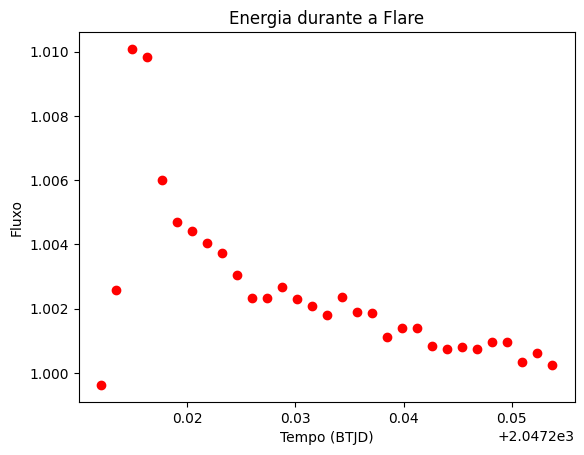

In [101]:
# Valores de início e término da flare (substitua pelos valores desejados)
start_input = 2047.2120
stop_input = 2047.2545

def ener_flare(start, stop, time, flux):
    flux_flare = []
    tempo_flare = []
    for i in range(len(time)):
        if time[i] >= start and time[i] <= stop:
            flux_flare.append(flux[i])
            tempo_flare.append(time[i])

    flux_flare = np.array(flux_flare)
    tempo_flare = np.array(tempo_flare)
    
    return flux_flare, tempo_flare

# Chamada da função ener_flare com os dados de exemplo
flux_flare, tempo_flare = ener_flare(start_input, stop_input, time, flux)
print(flux_flare)
print(tempo_flare)
# Criação do gráfico do tempo_flare em relação ao fluxo_flare
plt.plot(tempo_flare, flux_flare, 'ro')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()

In [102]:
##### Alguns dados básicos##################
fl129=pd.read_csv('flares_setor1.csv') #lendo os flares 
tess_f = pd.read_csv('tess_functionx1.csv') #lendo os arquivos da função de resposta
tf = pd.DataFrame(tess_f)
df = pd.DataFrame(fl129)

nm= np.array(tf["nm"]) # comprimento de onda em nm
ry= np.array(tf["ry"]) # tess function response

In [103]:

#Energia da flare
from PyAstronomy.pyasl import planck

#Mudança nm para cm e metro 
nm_metros = nm*(1e-9) #de nm para metros 
nm_cm = nm*(1e-7) #de nm para cm 

#Constantes importantes 
Teff= 3700# temperatura efetiva au mic
Tflare=10000# temperatura flare
raio=0.75*6.957e+10 # raio solar cm
sb1=5.67051e-5 #ergs cm-2*s-1*K-4

###########################
#Calculo da função de Planck
# Essa função (Bs=planck(Teff,lam=nm_metros)) da em [W/(m**2 m)] então
Bs=planck(Teff,lam=nm_metros)*1e-7 #multiplicação de *1e-7 para converter erg/(cm**2*A*s)
Bf=planck(Tflare,lam=nm_metros)*1e-7 #multiplicação de *1e-7 para converter erg/(cm**2*A*s)
##### Alguns dados básicos##################



1.44903515585565e+33


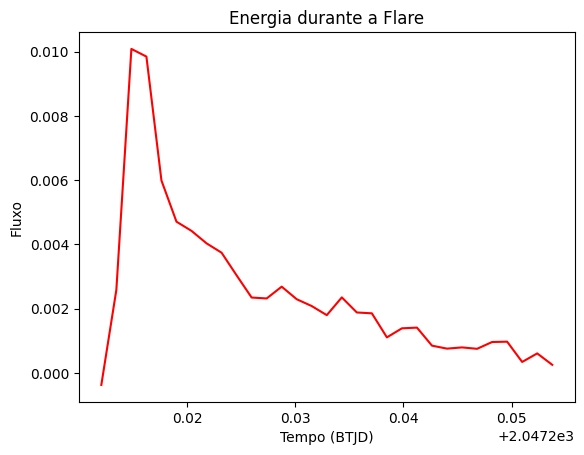

In [104]:
flux_flare1 = np.array(flux_flare)
tempo_flare1 = np.array(tempo_flare) 

# Fluxo relativo da estrela (valor mínimo de fluxo na região da flare)
f_rel_estrela = np.min(flux_flare1)

# Calcular a amplitude da flare (diferença entre o fluxo máximo da flare e o fluxo relativo da estrela)
amplitude_flare =  flux_flare1 - 1


# Integral
Aflare = amplitude_flare*np.pi*(raio**2) #(cm^2)

Aflare1 = simps(ry*Bs,nm_cm)/simps(ry*Bf,nm_cm)

# Área total da flare
Atotal = Aflare*Aflare1 #cm^2

# Luminosidade da flare
L = sb1*(Tflare**4)*Atotal #erg/s

# Energia bolométrica do flare

E1 = simps(L,tempo_flare1*86400) #erg



print(E1)

# Criação do gráfico do tempo_flare em relação ao fluxo_flare
plt.plot(tempo_flare1, amplitude_flare, 'r')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()

0.012613099999999933
0.010462140000000009


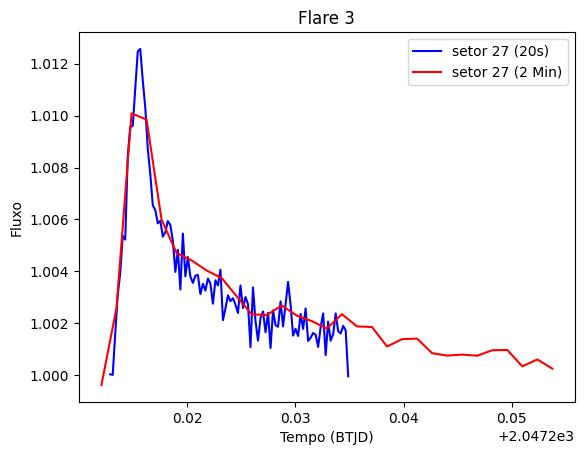

In [105]:
# Arrays fornecidos
array1 = [0.99962676, 1.0025866, 1.0100889, 1.00985, 1.0059928, 1.0047095, 1.0044236, 1.0040356, 1.0037441, 1.0030386, 1.0023478, 1.002319, 1.0026863, 1.002295, 1.0020822, 1.0017995, 1.0023522, 1.0018827, 1.001856, 1.0011076, 1.0013891, 1.0014111, 1.0008492, 1.0007565, 1.0007949, 1.0007513, 1.0009631, 1.0009732, 1.0003418, 1.0006081, 1.0002536]
array2 = [2047.21208554, 2047.21347445, 2047.21486337, 2047.21625229, 2047.21764121, 2047.21903013, 2047.22041905, 2047.22180797, 2047.22319689, 2047.22458581, 2047.22597473, 2047.22736365, 2047.22875257, 2047.23014148, 2047.2315304, 2047.23291932, 2047.23430824, 2047.23569716, 2047.23708608, 2047.238475, 2047.23986392, 2047.24125284, 2047.24264176, 2047.24403068, 2047.2454196, 2047.24680852, 2047.24819743, 2047.24958635, 2047.25097527, 2047.25236419, 2047.25375311]

# The first vector
fluxo_flare3  = [1.0000362, 1.0000123, 1.0016118, 1.0030869, 1.0039397, 1.0053757, 1.0052251, 1.0084622, 1.0095642, 1.0096091, 1.0124799, 1.0125711, 1.0113469, 1.0103121, 1.0087085, 1.0077469, 1.006548, 1.0063629, 1.005851, 1.005955, 1.0053389, 1.0055107, 1.0059414, 1.0057881, 1.0051923, 1.0039812, 1.0048318, 1.0033017, 1.0054564, 1.0038109, 1.0045545, 1.0038044, 1.0035571, 1.0038348, 1.0038661, 1.0031258, 1.0035187, 1.0032635, 1.0037255, 1.0035304, 1.0027555, 1.0036585, 1.0034578, 1.0040638, 1.0021207, 1.0025753, 1.0030797, 1.002851, 1.0029657, 1.0027173, 1.0023978, 1.0034585, 1.0025907, 1.0030128, 1.0027366, 1.001082, 1.0033848, 1.0020825, 1.0013317, 1.002206, 1.0024576, 1.0016556, 1.0024042, 1.0010484, 1.002498, 1.0019252, 1.0018674, 1.0028452, 1.0018796, 1.0035958, 1.0027142, 1.0015261, 1.0017896, 1.0015122, 1.0023634, 1.0017799, 1.002572, 1.0013227, 1.0014406, 1.0016271, 1.0015616, 1.0010908, 1.0018561, 1.0023822, 1.0007764, 1.002067, 1.0013304, 1.001586, 1.0023808, 1.0016961, 1.0016068, 1.0019004, 1.0017294, 0.999958]


tempo_flare3 = [2047.21289574, 2047.21312722, 2047.21335871, 2047.2135902, 2047.21382168, 2047.21405317, 2047.21428466, 2047.21451614, 2047.21474763, 2047.21497912, 2047.21544209, 2047.21567358, 2047.21590506, 2047.21613655, 2047.21636804, 2047.21659952, 2047.21683101, 2047.2170625, 2047.21729398, 2047.21752547, 2047.21775696, 2047.21798844, 2047.21821993, 2047.21845142, 2047.2186829, 2047.21891439, 2047.21914587, 2047.21937736, 2047.21960885, 2047.21984033, 2047.22007182, 2047.22030331, 2047.22053479, 2047.22076628, 2047.22099777, 2047.22122925, 2047.22146074, 2047.22169223, 2047.22192371, 2047.2221552, 2047.22238669, 2047.22261817, 2047.22284966, 2047.22308115, 2047.22331263, 2047.22354412, 2047.2237756, 2047.22400709, 2047.22423858, 2047.22447006, 2047.22470155, 2047.22493304, 2047.22516452, 2047.22539601, 2047.2256275, 2047.22585898, 2047.22609047, 2047.22632196, 2047.22655344, 2047.22678493, 2047.22701642, 2047.2272479, 2047.22747939, 2047.22771088, 2047.22794236, 2047.22817385, 2047.22840534, 2047.22863682, 2047.22886831, 2047.22933128, 2047.22956277, 2047.22979426, 2047.23002574, 2047.23025723, 2047.23048871, 2047.2307202, 2047.23095169, 2047.23118317, 2047.23141466, 2047.23164615, 2047.23187763, 2047.23210912, 2047.23234061, 2047.23257209, 2047.23280358, 2047.23303507, 2047.23326655, 2047.23349804, 2047.23372953, 2047.23396101, 2047.2341925, 2047.23442399, 2047.23465547, 2047.23488696]


amplitude_flare = max(fluxo_flare3) - min(fluxo_flare3)
amplitude_flare2 = max(array1) - min(array1)
print(amplitude_flare)
print(amplitude_flare2)

# Plotar os gráficos
plt.plot(tempo_flare3, fluxo_flare3, 'b', label='setor 27 (20s)')
plt.plot(array2, array1, 'r', label='setor 27 (2 Min)')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Flare 3')

# Adicionar a legenda
plt.legend()

# Mostrar o gráfico
plt.show()
